In [3]:
#Step 1 
#Inserting and loading the data
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv(r"C:\Users\udayb\Desktop\dataset\2026 QS World University Rankings.csv")
df.head()
print(df.shape)  # Shows (rows, columns)
df.tail()        # Shows last few rows

(1501, 30)


,2026 Rank,Previous Rank,Institution Name,Country/Territory,Region,Size,Focus,Research,Status,AR SCORE,...,ISR RANK,ISD SCORE,ISD RANK,IRN SCORE,IRN RANK,EO SCORE,EO RANK,SUS SCORE,SUS RANK,Overall SCORE
1496,1401+,1201-1400,University of West Bohemia,Czechia,Europe,M,CO,VH,Public,7.2,...,801+,4.8,801+,40.9,801+,15.5,801+,19.5,801+,-
1497,1401+,1201-1400,Voronezh State University,Russian Federation,Europe,L,CO,HI,Public,5.7,...,546,40.2,502,12.2,801+,3.5,801+,20.4,801+,-
1498,1401+,NaN,Walailak University,Thailand,Asia,L,FC,MD,Public,8.3,...,801+,7.4,801+,31.5,801+,3.2,801+,43.0,801+,-
1499,1401+,1201-1400,Yamaguchi University,Japan,Asia,M,FC,HI,Public,4.4,...,801+,8.9,801+,15.4,801+,1.7,801+,22.5,801+,-
1500,1401+,1201-1400,Youngsan University,Republic of Korea,Asia,M,SP,MD,Private for Profit,6.5,...,658,24.7,689,2.5,801+,1.9,801+,11.5,801+,-


In [4]:
#Step2 Cleaning the Data 
import pandas as pd

# Load the CSV file
file_path = r"C:\Users\udayb\Desktop\dataset\2026 QS World University Rankings.csv"
df = pd.read_csv(file_path)

# Preview raw column names
print("Original columns:")
print(df.columns.tolist())

# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('[^a-z0-9_]', '', regex=True)

# Drop rows where all values are missing
df.dropna(how='all', inplace=True)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Check for missing values
missing_summary = df.isnull().sum()
print("\nMissing values per column:")
print(missing_summary[missing_summary > 0])

# Convert 'rank' column to numeric (if it exists)
if 'rank' in df.columns:
    df['rank'] = pd.to_numeric(df['rank'], errors='coerce')

# Filter out rows without a valid rank
if 'rank' in df.columns:
    df = df[df['rank'].notnull()]

# Reset index
df.reset_index(drop=True, inplace=True)

# Preview cleaned data
print("\nCleaned dataset shape:", df.shape)
df.head()

Original columns:
['2026 Rank', 'Previous Rank', 'Institution Name', 'Country/Territory', 'Region', 'Size', 'Focus', 'Research', 'Status', 'AR SCORE', 'AR RANK', 'ER SCORE', 'ER RANK', 'FSR SCORE', 'FSR RANK', 'CPF SCORE', 'CPF RANK', 'IFR SCORE', 'IFR RANK', 'ISR SCORE', 'ISR RANK', 'ISD SCORE', 'ISD RANK', 'IRN SCORE', 'IRN RANK', 'EO SCORE', 'EO RANK', 'SUS SCORE', 'SUS RANK', 'Overall SCORE']

Missing values per column:
previous_rank    112
size               1
research           1
status            47
ifr_score         87
ifr_rank          87
isr_score         37
isr_rank          37
isd_score         37
isd_rank          37
irn_score          2
irn_rank           2
sus_score         24
sus_rank          24
dtype: int64

Cleaned dataset shape: (1501, 30)


,2026_rank,previous_rank,institution_name,countryterritory,region,size,focus,research,status,ar_score,...,isr_rank,isd_score,isd_rank,irn_score,irn_rank,eo_score,eo_rank,sus_score,sus_rank,overall_score
0,1,1,Massachusetts Institute of Technology (MIT),United States of America,Americas,M,CO,VH,Private not for Profit,100.0,...,153,92.3,130,94.1,98,100.0,7,93.8,33,100
1,2,2,Imperial College London,United Kingdom,Europe,L,FO,VH,Public,99.6,...,35,100.0,22,97.5,28,95.9,68,98.3,7=,99.4
2,3,6,Stanford University,United States of America,Americas,L,FC,VH,Private not for Profit,100.0,...,261,76.1,230,96.5,49,100.0,2,95.4,19=,98.9
3,4,3,University of Oxford,United Kingdom,Europe,L,FC,VH,Public,100.0,...,80,98.7,67,100.0,1,100.0,3,77.9,198=,97.9
4,5,4,Harvard University,United States of America,Americas,L,FC,VH,Private not for Profit,100.0,...,217,60.6,335,99.4,8,100.0,1,77.8,201=,97.7


In [5]:
#Exploratory Data Analysis 
# Basic info
df.info()

# Summary statistics
df.describe()

# Preview top rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1501 entries, 0 to 1500
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   2026_rank         1501 non-null   object 
 1   previous_rank     1389 non-null   object 
 2   institution_name  1501 non-null   object 
 3   countryterritory  1501 non-null   object 
 4   region            1501 non-null   object 
 5   size              1500 non-null   object 
 6   focus             1501 non-null   object 
 7   research          1500 non-null   object 
 8   status            1454 non-null   object 
 9   ar_score          1501 non-null   float64
 10  ar_rank           1501 non-null   object 
 11  er_score          1501 non-null   float64
 12  er_rank           1501 non-null   object 
 13  fsr_score         1501 non-null   float64
 14  fsr_rank          1501 non-null   object 
 15  cpf_score         1501 non-null   float64
 16  cpf_rank          1501 non-null   object 


,2026_rank,previous_rank,institution_name,countryterritory,region,size,focus,research,status,ar_score,...,isr_rank,isd_score,isd_rank,irn_score,irn_rank,eo_score,eo_rank,sus_score,sus_rank,overall_score
0,1,1,Massachusetts Institute of Technology (MIT),United States of America,Americas,M,CO,VH,Private not for Profit,100.0,...,153,92.3,130,94.1,98,100.0,7,93.8,33,100
1,2,2,Imperial College London,United Kingdom,Europe,L,FO,VH,Public,99.6,...,35,100.0,22,97.5,28,95.9,68,98.3,7=,99.4
2,3,6,Stanford University,United States of America,Americas,L,FC,VH,Private not for Profit,100.0,...,261,76.1,230,96.5,49,100.0,2,95.4,19=,98.9
3,4,3,University of Oxford,United Kingdom,Europe,L,FC,VH,Public,100.0,...,80,98.7,67,100.0,1,100.0,3,77.9,198=,97.9
4,5,4,Harvard University,United States of America,Americas,L,FC,VH,Private not for Profit,100.0,...,217,60.6,335,99.4,8,100.0,1,77.8,201=,97.7


In [6]:
#Top 20 Universities by Rank 
top20 = df.sort_values(by=['overall_score'],ascending=[True]).head(20)
top20[['overall_score', 'institution_name', 'countryterritory']]

,overall_score,institution_name,countryterritory
750,-,University of Malta,Malta
1005,-,"Aligarh Muslim University (AMU), Aligarh",India
1004,-,Alexandru Ioan Cuza University,Romania
1003,-,Al Azhar University,Egypt
1002,-,Aga Khan University,Pakistan
1001,-,Adamson University,Philippines
1000,-,Wuhan University of Technology,China (Mainland)
999,-,University of the Western Cape,South Africa
998,-,University of Massachusetts - Boston,United States of America
997,-,University of Lahore,Pakistan


C:\Users\udayb\AppData\Local\Temp\ipykernel_17340\2442193555.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


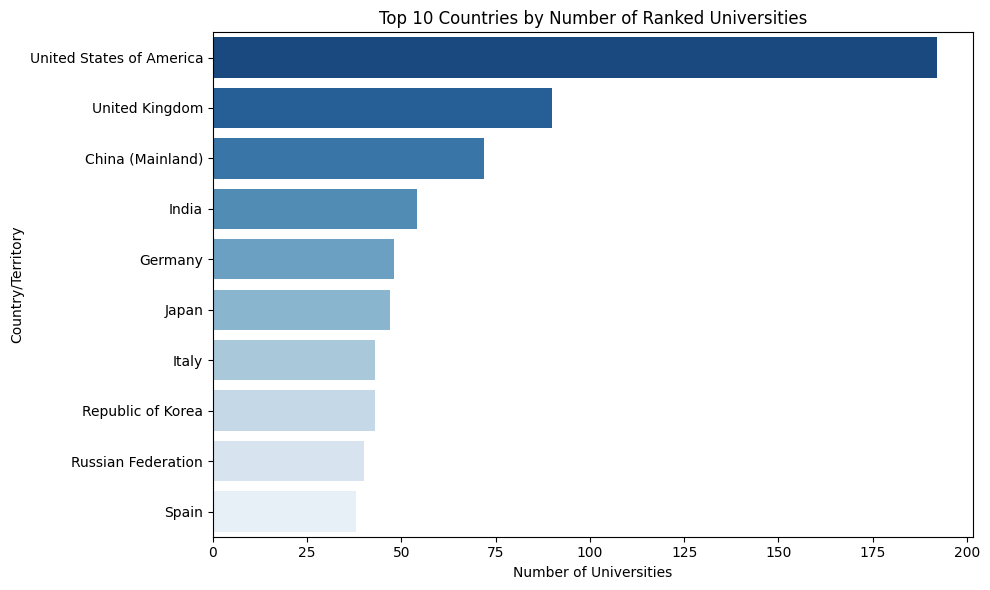

In [7]:
# This bar graph shows which countries have the most universities in the QS rankings.
# It's useful for identifying global dominance in higher education.

top_countries = df['countryterritory'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 10 Countries by Number of Ranked Universities')
plt.xlabel('Number of Universities')
plt.ylabel('Country/Territory')
plt.tight_layout()
plt.show()

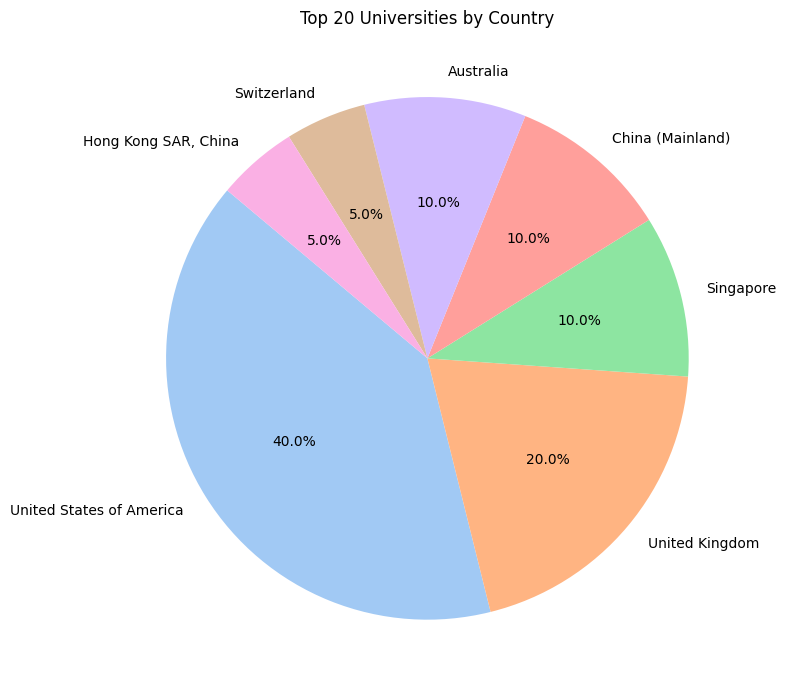

In [8]:
# This pie chart shows the country distribution of the top 20 universities by overall score.
# It helps visualize which countries dominate the highest ranks.

top20 = df.sort_values(by='overall_score', ascending=False).head(20)
country_counts = top20['countryterritory'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(country_counts.values, labels=country_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Top 20 Universities by Country')
plt.tight_layout()
plt.show()

C:\Users\udayb\AppData\Local\Temp\ipykernel_17340\2926827331.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


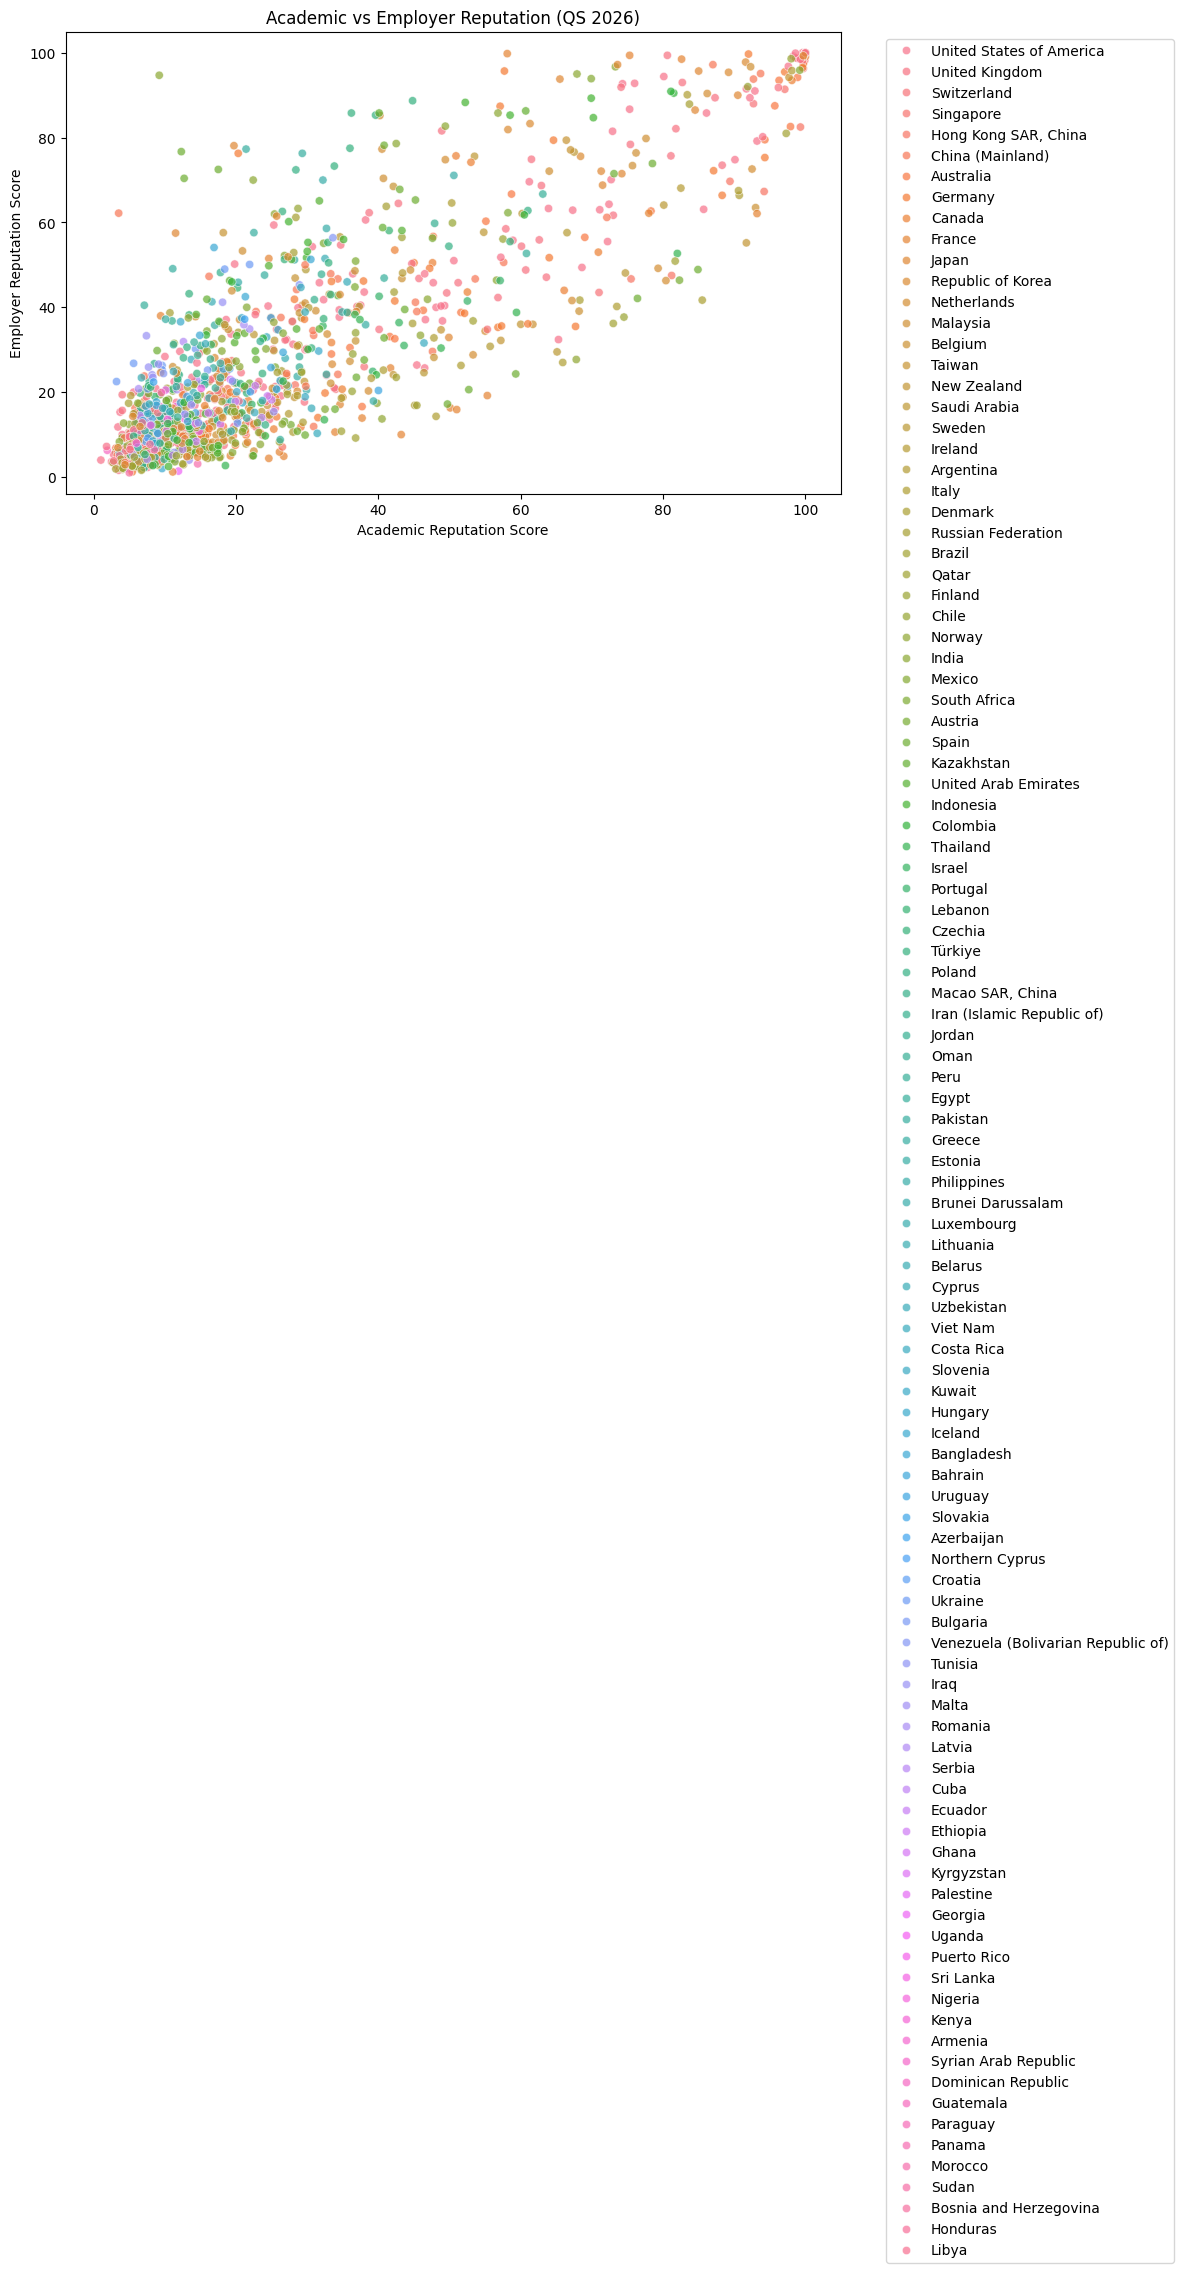

In [9]:
# This scatterplot compares academic reputation vs employer reputation for each university.
# It reveals whether top academic institutions are also favored by employers.

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='ar_score', y='er_score', hue='countryterritory', alpha=0.7)
plt.title('Academic vs Employer Reputation (QS 2026)')
plt.xlabel('Academic Reputation Score')
plt.ylabel('Employer Reputation Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show() 

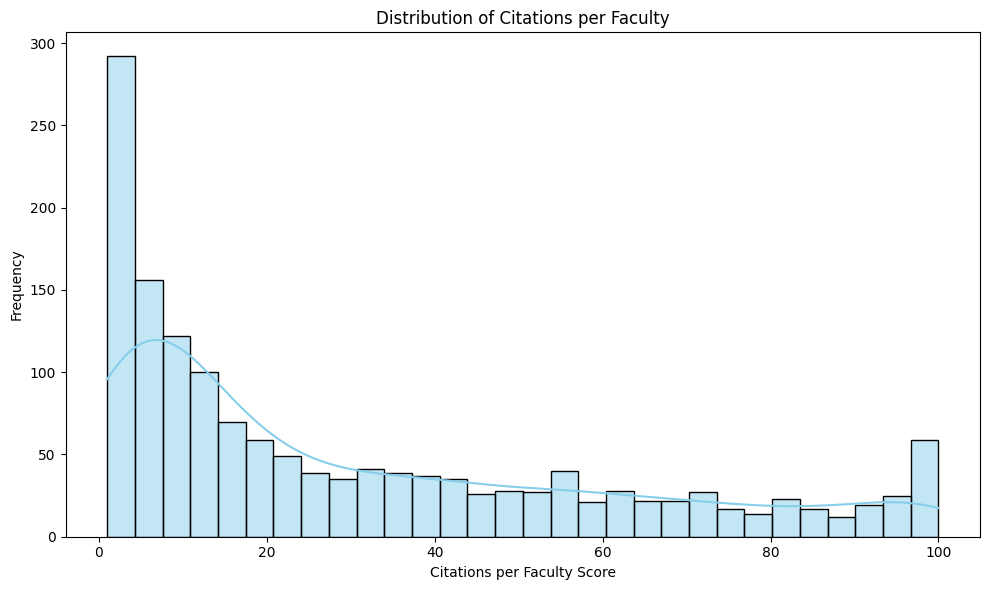

In [11]:
# This histogram shows the distribution of research impact across universities.
# Citations per faculty is a key metric for measuring research quality.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['cpf_score'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Citations per Faculty')
plt.xlabel('Citations per Faculty Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\udayb\AppData\Local\Temp\ipykernel_17340\1564204015.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='countryterritory', y='fsr_score', palette='Set2')


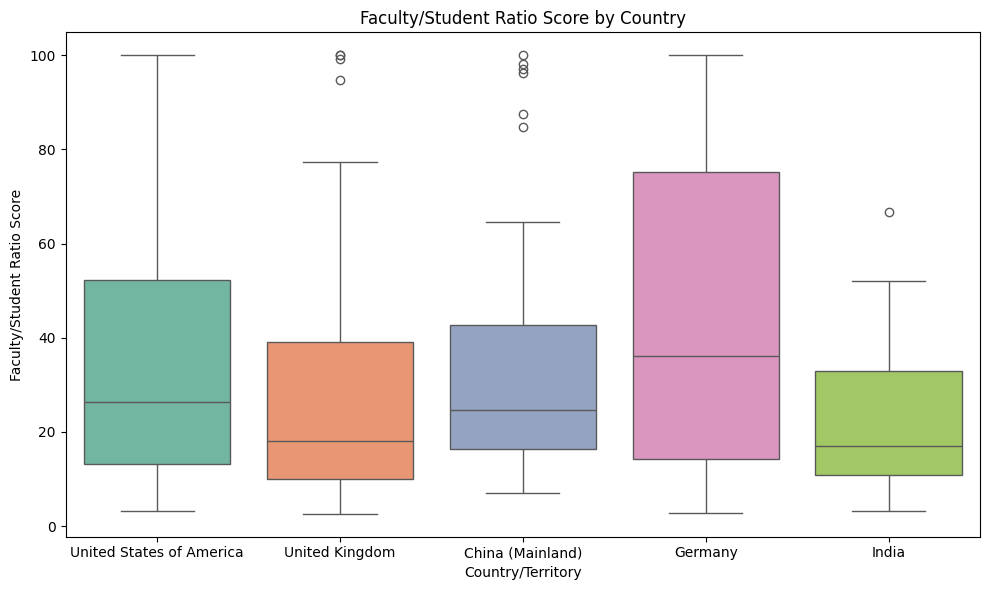

In [13]:
# This boxplot compares faculty/student ratio scores across the top 5 countries.
# It helps assess teaching capacity and student access to faculty.

import matplotlib.pyplot as plt
import seaborn as sns

# Get top 5 countries by number of universities
top_countries = df['countryterritory'].value_counts().head(5).index

# Filter dataset to include only those countries
subset = df[df['countryterritory'].isin(top_countries)]

# Create boxplot using correct column name: 'fsr_score'
plt.figure(figsize=(10,6))
sns.boxplot(data=subset, x='countryterritory', y='fsr_score', palette='Set2')
plt.title('Faculty/Student Ratio Score by Country')
plt.xlabel('Country/Territory')
plt.ylabel('Faculty/Student Ratio Score')
plt.tight_layout()
plt.show() 

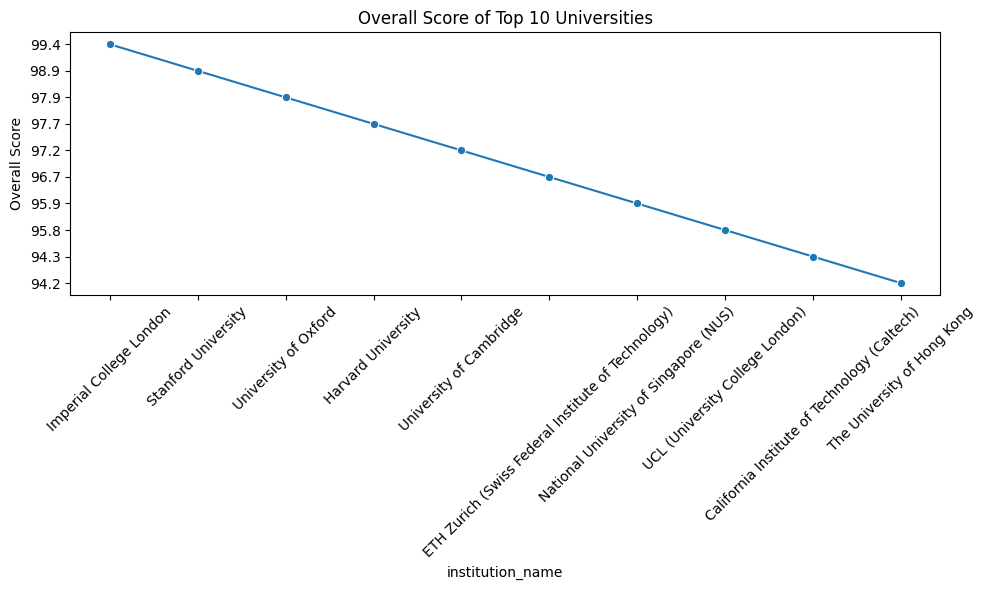

In [14]:
# This line plot shows the overall score of the top 10 universities.
# It helps compare performance levels and spot gaps between institutions.

top10 = df.sort_values(by='overall_score', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.lineplot(data=top10, x='institution_name', y='overall_score', marker='o')
plt.title('Overall Score of Top 10 Universities')
plt.xticks(rotation=45)
plt.ylabel('Overall Score')
plt.tight_layout()
plt.show() 

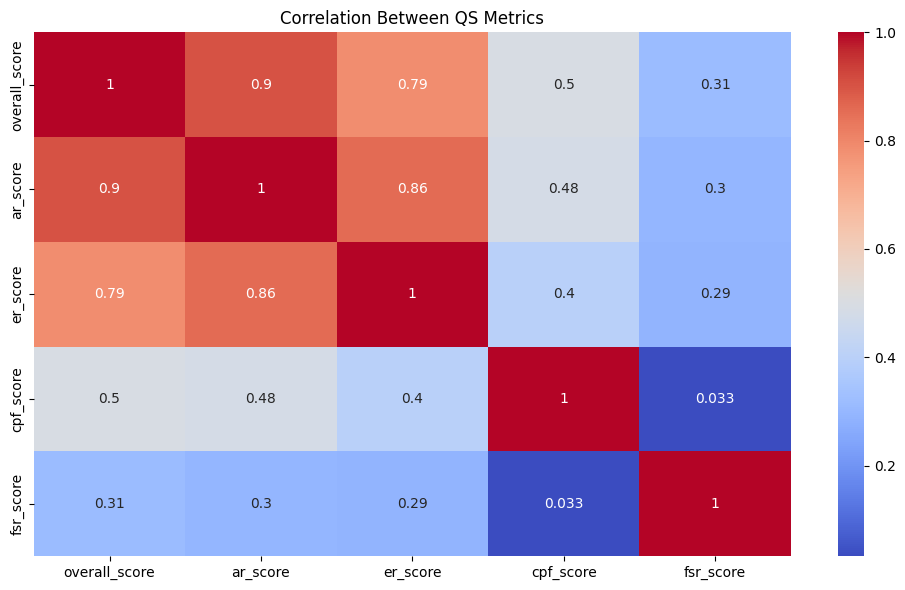

In [16]:
# This heatmap shows how different QS metrics relate to each other.
# It's useful for identifying which factors are most aligned with overall score.

import matplotlib.pyplot as plt
import seaborn as sns

# Convert overall_score to numeric (if it's still object type)
df['overall_score'] = pd.to_numeric(df['overall_score'], errors='coerce')

# Select correct columns for correlation
metrics = df[['overall_score', 'ar_score', 'er_score', 'cpf_score', 'fsr_score']]

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(metrics.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between QS Metrics')
plt.tight_layout()
plt.show() 

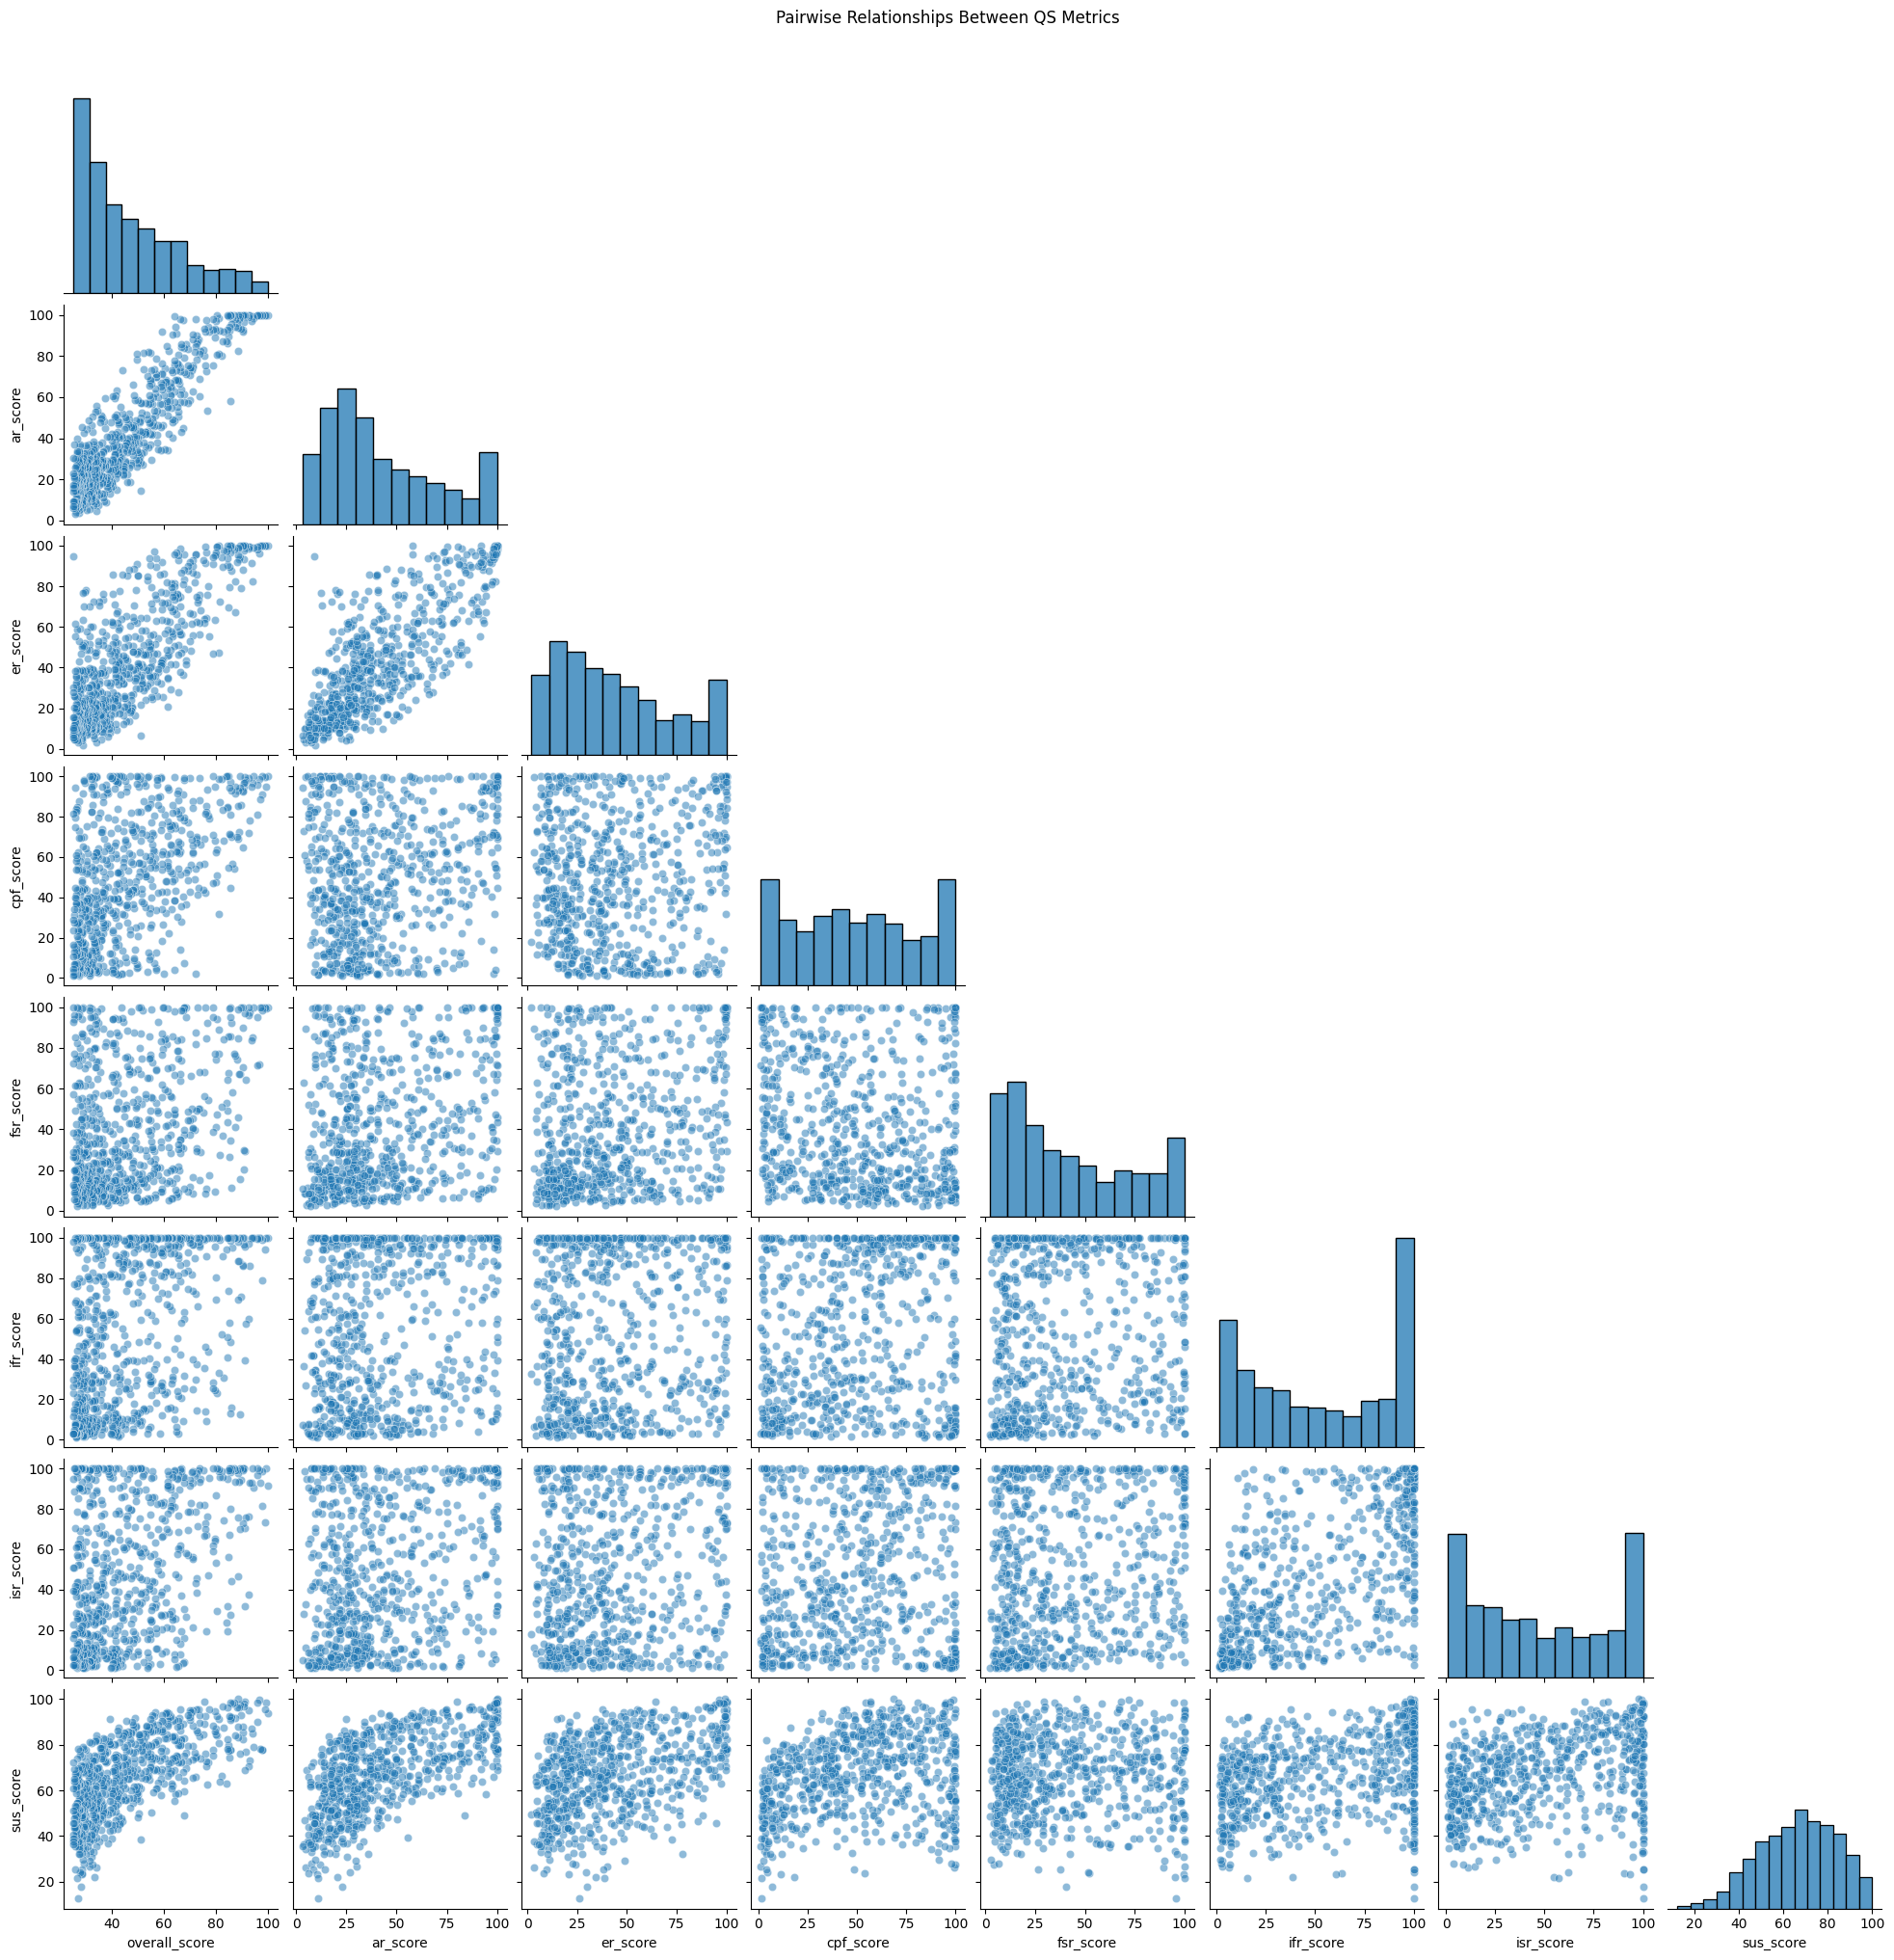

In [17]:
# 📊 PAIRPLOT: Visualizing relationships between multiple QS metrics

# WHY WE USE THIS:
# A pairplot is ideal for exploring pairwise relationships between several variables.
# It helps us detect correlations, clusters, and outliers across the dataset.
# This technique gives a compact, multi-angle view of how different ranking factors interact.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'overall_score' to numeric (if it's stored as string)
df['overall_score'] = pd.to_numeric(df['overall_score'], errors='coerce')

# Select key QS metrics for pairwise comparison
metrics = df[['overall_score', 'ar_score', 'er_score', 'cpf_score', 'fsr_score', 'ifr_score', 'isr_score', 'sus_score']]

# Drop rows with missing values to avoid plotting errors
metrics_clean = metrics.dropna()

# Create the pairplot
sns.pairplot(metrics_clean, corner=True, plot_kws={'alpha': 0.5})
plt.suptitle('Pairwise Relationships Between QS Metrics', y=1.02)
plt.show() 

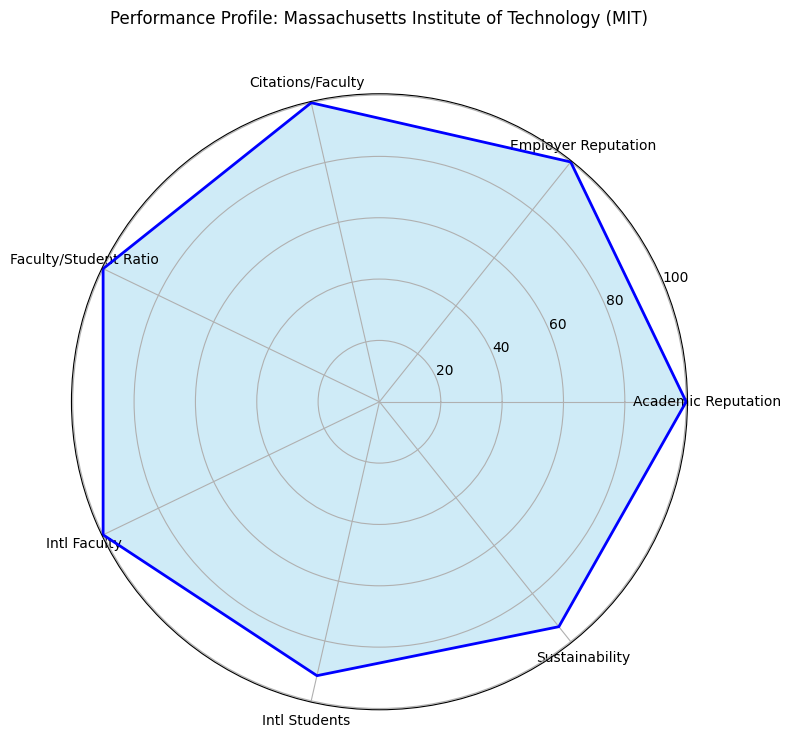

In [18]:
# 🧭 RADAR CHART: Visualizing a university's performance across multiple QS metrics

# WHY WE USE THIS:
# A radar chart is perfect for showing how a single university performs across many dimensions.
# It highlights strengths and weaknesses in a circular layout, making it easy to compare profiles.
# This technique is especially useful when analyzing balance vs specialization in rankings.

import numpy as np
import matplotlib.pyplot as plt

# Select the top-ranked university by overall score
top_uni = df.sort_values(by='overall_score', ascending=False).iloc[0]

# Define metric labels for the radar chart
labels = ['Academic Reputation', 'Employer Reputation', 'Citations/Faculty',
          'Faculty/Student Ratio', 'Intl Faculty', 'Intl Students', 'Sustainability']

# Extract corresponding scores from the top university
scores = [
    top_uni['ar_score'],
    top_uni['er_score'],
    top_uni['cpf_score'],
    top_uni['fsr_score'],
    top_uni['ifr_score'],
    top_uni['isr_score'],
    top_uni['sus_score']
]

# Prepare angles for radar chart (one per metric)
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()

# Close the radar chart loop by repeating the first value
scores += scores[:1]
angles += angles[:1]

# Create radar chart
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

# Plot the performance profile
ax.plot(angles, scores, color='blue', linewidth=2)
ax.fill(angles, scores, color='skyblue', alpha=0.4)

# Set labels and title
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title(f"Performance Profile: {top_uni['institution_name']}", y=1.1)

plt.show() 